In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv("../data/credit_card_fraud_10k.csv")  

In [3]:
df['trust_score_binned'] = pd.qcut(df['device_trust_score'], q=5, labels=False, duplicates='drop')

In [6]:
pd.qcut(df['device_trust_score'], q=5)

0         (54.0, 69.0]
1         (84.0, 99.0]
2         (40.0, 54.0]
3         (69.0, 84.0]
4         (69.0, 84.0]
             ...      
9995      (84.0, 99.0]
9996      (69.0, 84.0]
9997      (40.0, 54.0]
9998    (24.999, 40.0]
9999    (24.999, 40.0]
Name: device_trust_score, Length: 10000, dtype: category
Categories (5, interval[float64, right]): [(24.999, 40.0] < (40.0, 54.0] < (54.0, 69.0] < (69.0, 84.0] < (84.0, 99.0]]

In [4]:
df['amount_log'] = np.log1p(df['amount'])

In [5]:
X = df.drop(columns=['transaction_id', 'is_fraud', 'amount', 'device_trust_score'])
y = df['is_fraud']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [7]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', PowerTransformer(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [8]:
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [9]:
base_pipeline = Pipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        scale_pos_weight=scale_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [10]:
param_distributions = {
    'xgb__n_estimators': [100, 150, 200],
    'xgb__max_depth': [3, 4, 5, 6],                  
    'xgb__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 0.9],               
    'xgb__colsample_bytree': [0.7, 0.8, 0.9],        
    'xgb__gamma': [0, 0.1, 0.2]                      
}

In [11]:
search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_distributions,
    n_iter=10,                                       
    scoring='average_precision',                    
    cv=3,                                            
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [12]:
search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgb__colsample_bytree': [0.7, 0.8, ...], 'xgb__gamma': [0, 0.1, ...], 'xgb__learning_rate': [0.01, 0.03, ...], 'xgb__max_depth': [3, 4, ...], ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [13]:
best_pipeline = search.best_estimator_

In [19]:
y_train_pred = best_pipeline.predict(X_train)
y_train_proba = best_pipeline.predict_proba(X_train)[:, 1]


print("TRAINING SET CLASSIFICATION REPORT ")
print(classification_report(y_train, y_train_pred))

print(f"Train PR-AUC Score: {average_precision_score(y_train, y_train_proba):.4f}")
print(f"Train ROC-AUC Score: {roc_auc_score(y_train, y_train_proba):.4f}")

print(" TRAIN CONFUSION MATRIX ")
print(confusion_matrix(y_train, y_train_pred))

TRAINING SET CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7879
           1       0.91      1.00      0.95       121

    accuracy                           1.00      8000
   macro avg       0.95      1.00      0.98      8000
weighted avg       1.00      1.00      1.00      8000

Train PR-AUC Score: 0.9972
Train ROC-AUC Score: 1.0000
 TRAIN CONFUSION MATRIX 
[[7867   12]
 [   0  121]]


best_pipeline = search.best_estimator_

In [20]:
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("FINAL CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

print(f"PR-AUC Score (Primary Metric): {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC Score:                 {roc_auc_score(y_test, y_proba):.4f}")

print(" CONFUSION MATRIX ")
print(confusion_matrix(y_test, y_pred))

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1970
           1       0.64      1.00      0.78        30

    accuracy                           0.99      2000
   macro avg       0.82      1.00      0.89      2000
weighted avg       0.99      0.99      0.99      2000

PR-AUC Score (Primary Metric): 0.9831
ROC-AUC Score:                 0.9997
 CONFUSION MATRIX 
[[1953   17]
 [   0   30]]


In [22]:
fitted_preprocessor = best_pipeline.named_steps['prep']
X_train_processed = fitted_preprocessor.transform(X_train)
print("Shape of combined preprocessed feature matrix:", X_train_processed.shape)

Shape of combined preprocessed feature matrix: (8000, 12)


In [23]:
cat_encoder = fitted_preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + encoded_cat_cols

importances = best_pipeline.named_steps['xgb'].feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

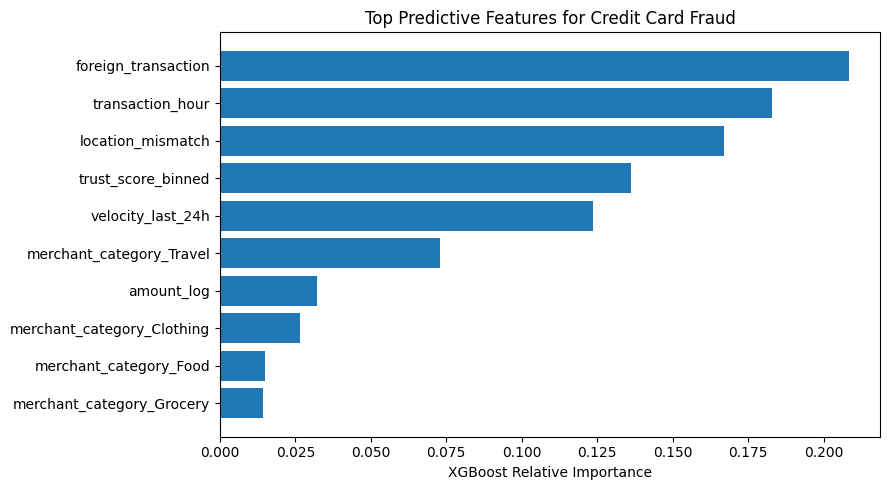

In [25]:
plt.figure(figsize=(9, 5))
plt.barh(feature_imp_df['Feature'][:10][::-1], feature_imp_df['Importance'][:10][::-1], color='#1f77b4')
plt.xlabel('XGBoost Relative Importance')
plt.title('Top Predictive Features for Credit Card Fraud')
plt.tight_layout()
plt.show()

In [28]:
joblib.dump(best_pipeline, "final_xgboost_fraud_pipeline.pkl")
print("Pipeline saved successfully!")

Pipeline saved successfully!
